In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math

In [4]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Functions for simulating data (need to save these in seperate python file in src)

In [5]:
# write function that takes in Cluster name 
def check_SS_cluster(cluster_name):
    
    # this cluster can also be used to label intron clusters as exon inclusion/exclusion event 
    juncs_c = junc_info[junc_info["Cluster"] == cluster_name]
    
    # keep only rows where either start or end appear twice
    s = np.array(juncs_c[juncs_c.duplicated(subset=['start'])].start.unique())
    e = np.array(juncs_c[juncs_c.duplicated(subset=['end'])].end.unique())
    juncs_c = juncs_c[(juncs_c["start"].isin(s)) | (juncs_c["end"].isin(e))]

    # if num rows in juncs_c is 3 then return cluster name 
    if len(juncs_c == 3):
        # confirm cluster has non zero counts in both cell types 
        num_celltypes = len(final_data[final_data.Cluster == cluster_name].cell_type.unique())
        if num_celltypes > 1:
            # confirm that each junction has non zero counts in both cell types
            counts_juncs = final_data[final_data.Cluster == cluster_name].junction_id.value_counts()
            counts_juncs = counts_juncs[counts_juncs > 1]
            num_cells=len(counts_juncs.index.unique())
            if num_cells == 3:
                return cluster_name
    else:
        pass

def simulate_junc_counts(cluster_counts, junc_info, cell_types=None, psi_prior_shape1=0.5, psi_prior_shape2=0.5):
    
    """Simulate junc counts while keeping the cluster counts of observed data. 
    
    Args: 
        cluster_counts: scipy coo_matrix. 
        cell_types: pandas Categorical series of pre-defined cell types to use for simulations 
        psi_prior_shape1: float.
        psi_prior_shape2: float.
    Returns:
        sim_junc_counts: scipy coo_matrix. 
        cell_type_labels: numpy array of cell type labels. 
        cell_type_psi: numpy array of cell type specific PSI values.
    """
    
    N, P = cluster_counts.shape  # number of cells, number of junctions
     
    # use real cell types labels to represent intron clusters being higher/lower in specific cell types 
    print("Using pre-defined cell types!")
    cell_type_labels = cell_types.cat.codes.to_numpy()
    K = len(cell_types.cat.categories)  # number of cell types
    
    print(N, P, K, len(cell_types))
    
    # number of intron clusters 
    num_clusters = len(junc_info.Cluster.unique())

    # label clusters as positive or negative by sampling 
    cluster_labels = np.random.choice([0, 1], size=num_clusters)

    # make a mapping of Cluster ID to cluster_labels
    cluster_labels_dict = dict(zip(junc_info.Cluster.unique(), cluster_labels))

    # initiate empty dataframe cell_type_psi_df to which we will append the simulated PSI values for each junction in each cell type
    cell_type_psi_df = pd.DataFrame()

    for clust in tqdm(junc_info.Cluster.unique()):
        clust_label = cluster_labels_dict[clust]
        # get cluster label
        # get junctions in cluster and order them by start and end 
        juncs_c = junc_info[junc_info["Cluster"] == clust]
        # order juncs_c by start and end
        juncs_c = juncs_c.sort_values(by=['start', 'end'])
        # assign J1, J2, and J3 to junctions where J1+J2 correspond to exon inclusion and J3 corresponds to exon skipping
        juncs_c["junction"] = ["J1", "J3", "J2"] 
        num_juncs = len(juncs_c)    
        if clust_label == 0: 
            # sample PSI values for each junction in each cell type via pre-defined beta distributions
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob 
            probs[1,] = probs[1,1]
            probs[0,] = (1-probs[1,1])/2
            probs[2,] = (1-probs[1,1])/2
            # convert probs to dataframe 
            probs_df = pd.DataFrame(probs.numpy())
            # add junction_id_index column to probs_df
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "negative"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # appent probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])
        elif clust_label == 1:
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob
            J3_prob = probs[1,]
            probs[0,] = (1-J3_prob)/2
            probs[2,] = (1-J3_prob)/2
            probs_df = pd.DataFrame(probs.numpy())
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "positive"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # use pd.concat to append probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])

    cell_type_psi_df = cell_type_psi_df.sort_values(by=['new_junction_id_index'])
    cell_type_psi = torch.tensor(cell_type_psi_df[[0,1]].to_numpy()) #should specify K columns insted of "0,1"
    print("Done simulating PSI!")

    # use real cluster counts to simulate junc counts with binomial distribution
    sim_junc_counts = cluster_counts.copy() 
    sim_junc_counts.data = torch.distributions.binomial.Binomial( 
         total_count=torch.tensor(cluster_counts.data), 
         probs=cell_type_psi[
             cluster_counts.col, # junction index
             cell_type_labels[cluster_counts.row] # cell index 
         ]
    ).sample().numpy()
    
    print("Done simulating junc counts!")
    
    return sim_junc_counts, cell_type_labels, cell_type_psi, cell_type_psi_df

# use sim_dat to get cluster level PSI for each cluster using J1+J2/J3 
def get_cluster_PSI(cluster, sim_data, junc_info):
    # cell clust counts 
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]

    # junction label info (J1, J2, J3)
    clust_dat = junc_info[junc_info["Cluster"] == cluster]
    clust_dat.sort_values(by = ["start", "end"], inplace = True)
    clust_dat["junc_label"] = ["J1", "J3", "J2"]
    clust_dat = clust_dat[["Cluster", "junc_label", "new_junction_id_index"]]
    # rename new_junction_id_index column to junction_id_index 
    clust_dat.rename(columns = {"new_junction_id_index": "junction_id_index"}, inplace = True)
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]
    #merge clust_dat with clust_only_counts 
    clust_only_counts = clust_only_counts.merge(clust_dat, on = ["Cluster", "junction_id_index"])
    clust_only_counts = clust_only_counts[["cell_id_index", "Cluster", "junction_id_index", "junc_count", "cluster_count", "junc_label"]]
    clust_only_counts.sort_values(by = ["cell_id_index", "junction_id_index"], inplace = True)
    
    clust_only_counts_mat = clust_only_counts.pivot(index = "junction_id_index", columns = "cell_id_index", values = "junc_count")
    cols_names = list(clust_only_counts_mat)
    clust_only_counts_mat["junc_label"] = clust_only_counts[["junction_id_index", "junc_label"]].drop_duplicates()["junc_label"].values
    # reorder rows using junc_label
    clust_only_counts_mat.sort_values(by = ["junc_label"], inplace = True)
    # for each column calculate J1+J2/J1+J2+J3
    # for each cell in each column sum first two rows and divide by sum of all three rows
    clust_cells_psi = []
    for i in cols_names:
        col_index = clust_only_counts_mat.columns.get_loc(i)
        psi_value = clust_only_counts_mat.iloc[2,col_index].sum() / clust_only_counts_mat.iloc[:,col_index].sum()
        # save cell index (i), cluster and psi value
        clust_cells_psi.append([i, cluster, psi_value])

    # convert clust_cells_psi to dataframe
    clust_cells_psi = pd.DataFrame(clust_cells_psi, columns = ["cell_id_index", "Cluster", "cluster_psi"])
    return(clust_cells_psi)

### Settings and Load data

In [6]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 5 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.2


In [7]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, celltypes=['Brain_Non-Myeloid_neuron', 'Brain_Non-Myeloid_brain_pericyte'], max_intron_count=5000) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_neuron', 'Brain_Non-Myeloid_brain_pericyte']
['Brain_Non-Myeloid_brain_pericyte' 'Brain_Non-Myeloid_neuron']
437
12167
The maximum junction count was initially:  5978
4
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
1  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
2  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       10              16   
3  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       27               7   
4  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       28              12   

             junction_id        gene_id  junc_count  \
0  1_160044753_160

### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [8]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

1733


In [9]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()):
    clusters_SS.append(check_SS_cluster(cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

100%|██████████| 1733/1733 [00:08<00:00, 209.15it/s]


1254
3762
   junction_id_index            junction_id  Cluster  new_junction_id_index
0                  0  1_160044753_160070699        4                      0
1                  1  1_160070803_160075030        4                      1
2                  8  1_171329526_171338251       90                      2
3                  9    1_34299838_34301860       99                      3
4                 10    1_34301932_34302829       99                      4
cell_id_index                                                          155
junction_id_index                                                      348
junc_count                                                            36.0
cluster_count                                                           41
clustminjunc                                                           5.0
juncratio                                                         0.878049
cell_id                  P21-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...
cell_type

### Ready to simulate some data!

In [10]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_160044753_160070699,4,0,1,160044753,160070699,0
1,1_160070803_160075030,4,1,1,160070803,160075030,1
2,1_171329526_171338251,90,8,1,171329526,171338251,2
3,1_34299838_34301860,99,9,1,34299838,34301860,3
4,1_34301932_34302829,99,10,1,34301932,34302829,4


In [11]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
437 3762 2 437


100%|██████████| 1254/1254 [00:03<00:00, 340.99it/s]


Done simulating PSI!
Done simulating junc counts!


In [12]:
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

In [13]:
cell_type_psi_df["difference"] = cell_type_psi_df[0] - cell_type_psi_df[1]
cell_type_psi_df.head()

,0,1,new_junction_id_index,sample_label,Cluster,difference
0,0.422694,0.422694,0,negative,4,0.000000
2,0.422694,0.422694,1,negative,4,0.000000
1,0.329157,0.837090,2,positive,90,-0.507933
0,0.253225,0.253225,3,negative,99,0.000000
2,0.253225,0.253225,4,negative,99,0.000000


In [14]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.head()

,0,1,new_junction_id_index,sample_label,Cluster,difference,true_label
0,0.422694,0.422694,0,negative,4,0.000000,negative
2,0.422694,0.422694,1,negative,4,0.000000,negative
1,0.329157,0.837090,2,positive,90,-0.507933,positive
0,0.253225,0.253225,3,negative,99,0.000000,negative
2,0.253225,0.253225,4,negative,99,0.000000,negative


In [15]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,6.0,0
1,0,1,12.0,0
2,0,2,2.0,0
3,0,3,1.0,0
4,0,4,5.0,0


In [16]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,11.0,21,10.0,0.523810,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,6.0,0
1,119,0,21.0,53,32.0,0.396226,M14-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,19.0,0
2,120,0,11.0,26,15.0,0.423077,M15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,11.0,0
3,121,0,91.0,180,89.0,0.505556,M21-MAA000424-3_11_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,71.0,0
4,122,0,3.0,4,1.0,0.750000,M21-MAA001894-3_39_F-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,0.0,0


In [17]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type
0,0,21,10.0,0.523810,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,6.0,0
1,119,53,32.0,0.396226,M14-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,19.0,0
2,120,26,15.0,0.423077,M15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,11.0,0
3,121,180,89.0,0.505556,M21-MAA000424-3_11_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,71.0,0
4,122,4,1.0,0.750000,M21-MAA001894-3_39_F-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,1_160044753_160070699,4,0,0.0,0


In [18]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

In [19]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

In [20]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
437
437


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [21]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,4,Brain_Non-Myeloid_brain_pericyte,0,0.300000,6.0,20.0,negative
1,0,4,Brain_Non-Myeloid_brain_pericyte,1,0.600000,12.0,20.0,negative
2,0,4,Brain_Non-Myeloid_brain_pericyte,880,0.100000,2.0,20.0,negative
3,119,4,Brain_Non-Myeloid_brain_pericyte,0,0.395833,19.0,48.0,negative
4,119,4,Brain_Non-Myeloid_brain_pericyte,1,0.520833,25.0,48.0,negative


In [22]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.sample_label.unique()[0]
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

In [23]:
simple_data.Cluster.unique()

array([   4,   90,   99, ..., 7078, 3010,  344])

Brain_Non-Myeloid_neuron            102
Brain_Non-Myeloid_brain_pericyte     57
Name: cell_type, dtype: int64


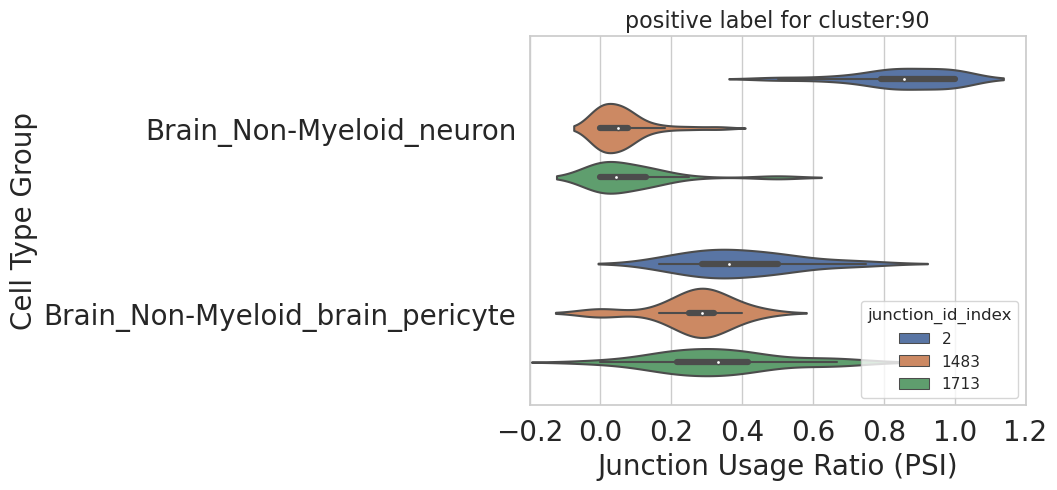

In [24]:
# let's visualize junction usage ratios for a given custer 
clust = 90
quick_clust_plot(clust, simple_data)

In [25]:
def model(y, total_counts, K):
  N,P = y.shape

  # total_counts should be of shape N,P cells by junctions

  # pyro.sample declares random variables (first arguement is the name assigned to it)
  # can also encode dependencies in these random variables such as
  # # Define another random variable 'y' dependent on 'x'
  # y = pyro.sample("y", dist.Normal(x, 1))

  a = pyro.sample("a", dist.Gamma(1.,1.).expand([P]).to_event(1)) # per junction to model average behaviour
  b = pyro.sample("b", dist.Gamma(1.,1.).expand([P]).to_event(1))

  psi_dist = dist.Beta(a,b).expand([K,P]).to_event(2)
  psi_dist = dist.Beta(1.,1.).expand([K,P]).to_event(2)  # simpler non-hierarchical version
  psi = pyro.sample("psi", psi_dist)

  pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K)/K))
  conc = pyro.sample("conc", dist.Gamma(1,1))

  # In Pyro, pyro.plate is used to declare that a set of sample statements are
  # conditionally independent given a particular dimension or plate. It helps
  #Pyro to perform efficient inference by taking advantage of this conditional independence.

  with pyro.plate('data1', N):
    # So, for each cell (i.e., for each value of the plate dimension),
    # you independently sample from the assign_dist, which is a Dirichlet
    # distribution parameterized by pi * conc. This allows each cell to have
    #its own distribution over cell states, and the assignments of cell states
    #to cells are considered independent of each other.
    assign_dist = dist.Dirichlet(pi * conc)
    # assign_dist = dist.Dirichlet(torch.ones(K)) # simpler non-hierarchical version
    assign = pyro.sample("assign", assign_dist)

  # so assign is N,K
  # and psi is K,P
  # even with masking below this step would still take a bunch of time 
  # calculating for all N and J
  pred = assign @ psi # -> dim N by J 

  # maybe try https://pytorch.org/docs/stable/generated/torch.einsum.html here for this operation above ? 
  # make sure that you can do backprop through them 

  # so pred is N, P which is inferred PSI of each junction for each cell depending on which assign factor it belongs to
  # Each element in pred row (along N) corresponds to the PSI value for a specific junction or event in that cell.
  with pyro.plate('dims', P): # This outer plate indicates that the dimensions (junctions) are independent of each other across all data points (cells).
    with pyro.plate('data', N): #This inner plate indicates that the cells are independent of each other. Within each cell, you have multiple junctions (dimensions), and the inner plate makes it clear that you're modeling each cell's data independently.
      obs = pyro.sample('obs', dist.Binomial(total_counts, pred), obs=y)
      # try using our own dist.Binomial custom function, any entry where the count is zero would return 0 and ignore the normalization term 

  # Create a mask where y and total_counts are not -1
  # mask_na = (y != -1) & (total_counts != -1)
  #with pyro.plate('data', P):
  #  with pyro.plate('dims', N):
  #    obs = pyro.sample('obs', dist.Binomial(total_counts.flatten(), pred.flatten()).mask(mask_na.flatten()), obs=y.flatten())

def fit(y, total_counts, K, guide):
  adam = pyro.optim.Adam({"lr": 0.03})
  svi = SVI(model, guide, adam, loss=Trace_ELBO())
  pyro.clear_param_store()
  losses = []
  time_per_iter = []
  for j in range(1000):
      loss = svi.step(y, total_counts, K)
      losses.append(loss)
  return losses

In [26]:
def get_posterior_stats(
    model,
    guide,
    data,
    num_samples=100
):

    """ extract posterior samples (somewhat weirdly this is done with `Predictive`) """
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples)

    samples = predictive(*data) ## get posterior samples
    posterior_stats = { k : {
                "mean": torch.mean(v, 0),
                "std": torch.std(v, 0),
                "5%": v.kthvalue(int(len(v) * 0.05), dim=0)[0],
                "95%": v.kthvalue(int(len(v) * 0.95), dim=0)[0],
            } for k, v in samples.items() }

    return posterior_stats

In [27]:
y = sim_data[["cell_id_index", "junction_id_index", "junc_count"]]
# Pivot the DataFrame to create a matrix with rows as cell IDs and columns as junction IDs
y = y.pivot(index="cell_id_index", columns="junction_id_index", values="junc_count")
# Replace missing values (NaN) with 0
y = y.fillna(0)
# Convert the DataFrame to a NumPy array and then to a PyTorch tensor
y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32)
y_tensor

tensor([[ 6., 12.,  2.,  ...,  0.,  0.,  2.],
        [49., 48.,  0.,  ...,  0.,  0.,  3.],
        [10.,  7.,  0.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  7.,  ...,  0.,  0.,  2.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])

In [28]:
# other way 
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor_coo = torch.sparse_coo_tensor(indices, values, size)
y_tensor_coo

tensor(indices=tensor([[   0,    0,    0,  ...,  182,  182,  182],
                       [   0,    1,  880,  ..., 2922, 3213, 3441]]),
       values=tensor([ 6., 12.,  2.,  ...,  2.,  1.,  0.]),
       size=(437, 3762), nnz=419766, layout=torch.sparse_coo)

In [29]:
total_counts = sim_data[["cell_id_index", "junction_id_index", "cluster_count"]]
# Pivot the DataFrame to create a matrix with rows as cell IDs and columns as junction IDs
total_counts = total_counts.pivot(index="cell_id_index", columns="junction_id_index", values="cluster_count")
# Replace missing values (NaN) with 0
total_counts = total_counts.fillna(0)
# Convert the DataFrame to a NumPy array and then to a PyTorch tensor
total_counts_tensor = torch.tensor(total_counts.to_numpy(), dtype=torch.float32)
total_counts_tensor

tensor([[ 20.,  20.,   4.,  ...,   0.,   0.,   2.],
        [118., 118.,   0.,  ...,   0.,   0.,   3.],
        [ 20.,  20.,   0.,  ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  0.,   0.,   7.,  ...,   0.,   0.,   8.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   7.]])

In [30]:
K = 50 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

guide = AutoDiagonalNormal(model)
print(guide)

437 3762 50
AutoDiagonalNormal()


In [31]:
K = 2 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

437 3762 2


In [32]:
guide = AutoDiagonalNormal(model)
guide

AutoDiagonalNormal()

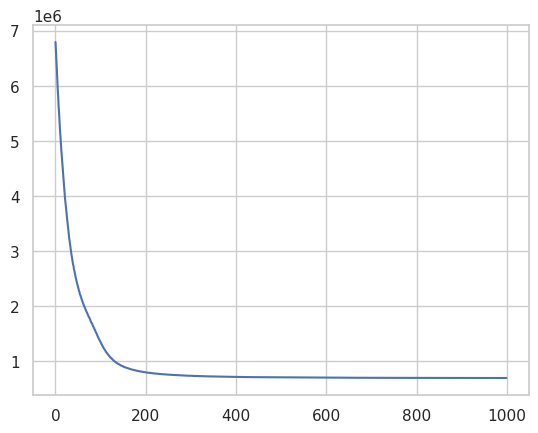

In [33]:
losses = fit(y_tensor, total_counts_tensor, K, guide)
plt.plot(losses, label = "Diagonal variational posterior")

In [34]:
ps = get_posterior_stats(model, guide, data = [y_tensor, total_counts_tensor, K])

In [35]:
ps["pi"]["mean"]

tensor([[[0.4088, 0.5912]]])

In [36]:
ps["conc"]

{'mean': tensor([[0.3931]]),
 'std': tensor([[0.0197]]),
 '5%': tensor([[0.3606]]),
 '95%': tensor([[0.4217]])}

In [37]:
# can we plot assign probabilityies for each cell
assign_post = ps["assign"]["mean"]
# convert to 2d from 3d dont need first dimension
assign_post = assign_post[0,:,:]
# plot N cells by K factors but just frist two factors scatter plot
assign_post

tensor([[0.9921, 0.0079],
        [0.9905, 0.0095],
        [0.9847, 0.0153],
        [0.9958, 0.0042],
        [0.9966, 0.0034],
        [0.9932, 0.0068],
        [0.9956, 0.0044],
        [0.9927, 0.0073],
        [0.9953, 0.0047],
        [0.9923, 0.0077],
        [0.9949, 0.0051],
        [0.9967, 0.0033],
        [0.9960, 0.0040],
        [0.9924, 0.0076],
        [0.9964, 0.0036],
        [0.9956, 0.0044],
        [0.9960, 0.0040],
        [0.9966, 0.0034],
        [0.9970, 0.0030],
        [0.9967, 0.0033],
        [0.9953, 0.0047],
        [0.9892, 0.0108],
        [0.9964, 0.0036],
        [0.9925, 0.0075],
        [0.9969, 0.0031],
        [0.9933, 0.0067],
        [0.9861, 0.0139],
        [0.9969, 0.0031],
        [0.9943, 0.0057],
        [0.9857, 0.0143],
        [0.9971, 0.0029],
        [0.9957, 0.0043],
        [0.9953, 0.0047],
        [0.9919, 0.0081],
        [0.9944, 0.0056],
        [0.9935, 0.0065],
        [0.9928, 0.0072],
        [0.9951, 0.0049],
        [0.9

In [38]:
cell_ids_conversion

,cell_id_index,cell_id,cell_type
0,0,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
1041,1,A14-MAA000930-3_8_M-1-1_Brain_Non-Myeloid_brai...,Brain_Non-Myeloid_brain_pericyte
2047,2,A14-MAA000947-3_9_M-1-1_Brain_Non-Myeloid_brai...,Brain_Non-Myeloid_brain_pericyte
2699,3,A15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
3895,4,A19-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
...,...,...,...
3684400,432,P3-MAA000940-3_8_M-1-1_Brain_Non-Myeloid_neuron,Brain_Non-Myeloid_neuron
3685402,433,P5-MAA000940-3_8_M-1-1_Brain_Non-Myeloid_neuron,Brain_Non-Myeloid_neuron
3686328,434,P7-B000404-3_56_F-1-1_Brain_Non-Myeloid_neuron,Brain_Non-Myeloid_neuron
3686794,435,P7-MAA000925-3_9_M-1-1_Brain_Non-Myeloid_neuron,Brain_Non-Myeloid_neuron


Text(0.5, 1.0, 'Cell Assignments')

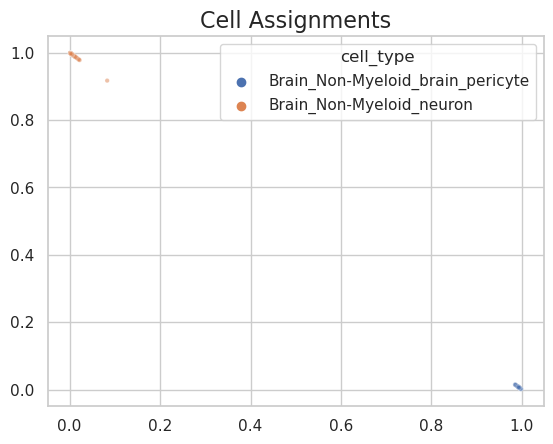

In [42]:
# color point by cell_ids_conversion["cell_type"] and reduce point size and alpha
sns.scatterplot(x=assign_post[:,0], y=assign_post[:,1], hue=cell_ids_conversion["cell_type"], s=10, alpha=0.5)
# add title 
plt.title("Cell Assignments", fontsize=16)

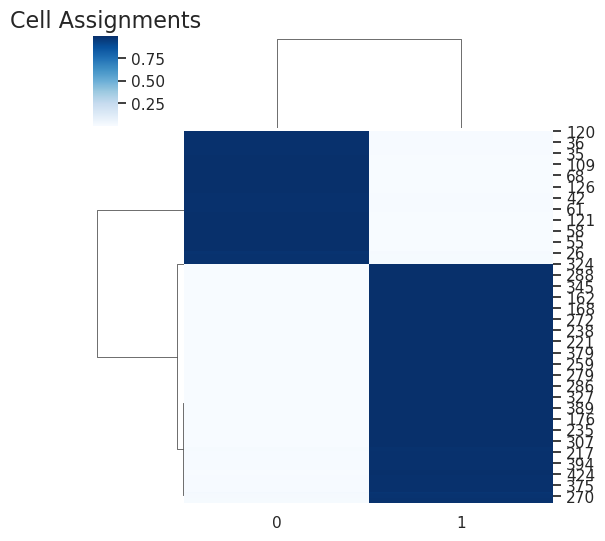

In [45]:
# do the K factors capture the simulated cell types?
# plot clustermap N by K from assign_post
sns.clustermap(assign_post, cmap="Blues")
# add title 
plt.title("Cell Assignments", fontsize=16)
# reduce figure size 
plt.gcf().set_size_inches(5, 5)

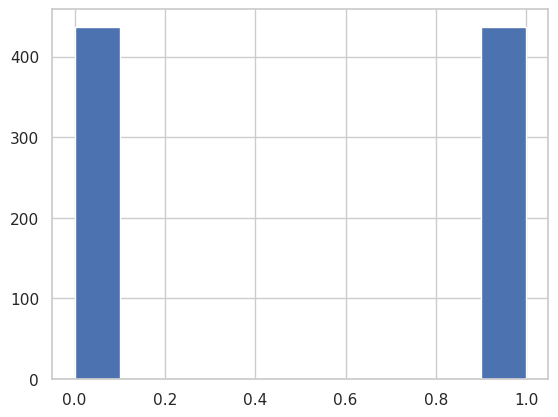

In [41]:
plt.hist(ps["assign"]["mean"].numpy().flatten())
plt.show()